In [ ]:
import jax
from jax import numpy as jnp
import matplotlib.pyplot as plt
import pickle

# Tutorial 2 — J₁–J₂ model: SR

In this second tutorial, using the J1J2 model (see tutorial 1), we show how the **symbolic regression (SR)** tools implemented in qdisc can be used. These methods aim to identify **compact analytic descriptors** of latent clusters, which can often be interpreted as candidate order parameters.

The main entry point is the `qdisc.sr.SymbolicRegression()` class. It is initialized by specifying the following attributes:

- the dataset (an instance of `qdisc.Dataset`),
- the index (in $\theta$-space) of the cluster to be analyzed,
- the objective used to define the loss / fitness function:
  - a **classification objective** (SR1),
  - a **boundary-matching objective** in $x$-space (SR2),
  - a **boundary-matching objective** in $\theta$-space (SR3),
- for SR1, the indices of data points labeled as outside the cluster,
- For SR2 and SR3, the VAE should also be given with the index of the latent variable where the cluster appear
- for SR3, the method used to construct the projector $v_k$ (currently `'delta'` or `'cp'`).

In addition, the **search space** of the symbolic expression must be specified. qdisc currently supports two options:
- a **two-body correlator ansatz**,
  $$
  f(x) = \sum_{i,j>i} \alpha_{i,j}\, x_i x_j + b,
  $$
- a more expressive search space based on **genetic programming**. By setting the option to `'genetic'`, qdisc interfaces with **PySR**. For the moment, this is only available with the SR1 objective. For further details, we refer the reader to the PySR documentation: https://github.com/MilesCranmer/PySR

In the following, we use qdisc to identify a symbolic expression characterizing the **Néel phase**, employing the two-body correlator ansatz and comparing the different symbolic regression objectives.


In [ ]:
## load/create the necessary objects
from qdisc.nn.core import EncoderCNN2D, ARNNDense
from qdisc.vae.core import VAEmodel
from qdisc.sr.core import SymbolicRegression
from qdisc.sr.core import spearman_rho
from qdisc.sr.core import auc_from_scores_labels
from qdisc.dataset.core import Dataset

#dataset
with open('J1J2_data_cpVAE2_QDisc.pkl', 'rb') as f:
    all_data = pickle.load(f)

all_J2 = jnp.linspace(0, 1.5, 21)
all_h = jnp.linspace(0, 2., 21)[1:]

dataset = Dataset(data=all_data['data'], thetas=[all_J2, all_h], data_type='discrete', local_dimension=2, local_states=jnp.array([0,1]))

#vae
N = 9
encoder = EncoderCNN2D(latent_dim=5, conv_features = 4*N, dense_features = 4*N, num_conv_layers=3)
decoder = ARNNDense(num_layers=4, features=4*N)

VAE_model = VAEmodel(encoder=encoder, decoder=decoder)
VAE_params = all_data['params']
latvar = all_data['latvar']

## classifying the Neel phase

We first try to look for a compact expression f(x) characterizing the Néel phase, which is defined bellow:

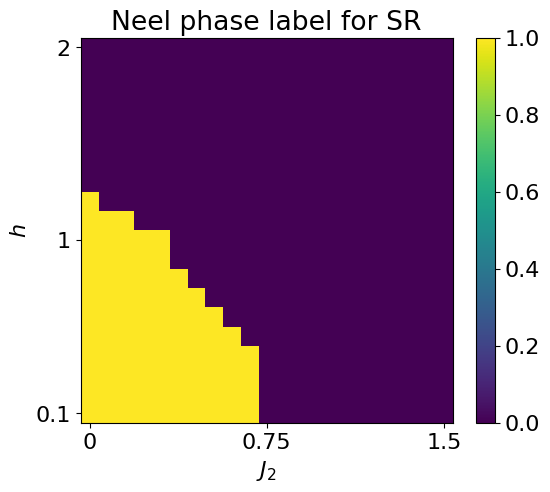

In [ ]:
## we first specify the indexe of the cluster ##
# could use the GMM results, in this toy example, can also just set a threshold
mu0abs = latvar['mu0_abs']
threshold = 0.5
# ! the idx are related to dataset thetas order, if latvar were computed using (1,0) order (as before), need to transpose 
cluster_idx_in_neel = jnp.argwhere(mu0abs.transpose()<threshold)

# also compute a label array (used later to compute the auc)
labels_neel = jnp.zeros_like(jnp.mean(dataset.data, axis=(-1,-2)))
for id in cluster_idx_in_neel:
  labels_neel = labels_neel.at[id[0],id[1]].set(1)
labels_neel = labels_neel[:10,:].reshape(-1)


plt.rcParams['font.size'] = 16
plt.figure(figsize=(6,5),dpi=100)

plt.imshow(jnp.flipud(mu0abs<threshold), aspect='auto')
plt.colorbar()
plt.title(r'Neel phase label for SR')
plt.yticks([0,10,19], ['2', '1', '0.1'])
plt.xticks([0, 10, 20], ['0', '0.75', '1.5'])
plt.ylabel(r'$h$')
plt.xlabel(r'$J_2$')
plt.show()

After initializing a `SymbolicRegression` object, the symbolic search can be launched by simply calling the `.train()` method.

For the two-body correlator ansatz, qdisc provides visualization utilities to help interpret the learned expression. In particular, the `.plot_alpha()` method displays the learned coefficients $\alpha_{i,j}$, given the specified topology of the quantum system.

Once a symbolic expression $f(x)$ is obtained, its predictions can be computed and visualized using the `.compute_and_plot_prediction()` method.

Finally, to quantify the quality of the symbolic descriptor $f(x)$, one can compute the **Spearman correlation coefficient** between the model predictions and a reference physical observable (here, the nearest-neighbour correlator).


### Start preparing the dataset ###
### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 0.3136450401569233
        x: [ 1.095e-01  5.870e-02 ...  1.315e-01  4.198e-01]
      nit: 24
      jac: [ 5.185e-06 -3.036e-06 ...  2.331e-07 -5.995e-07]
     nfev: 1036
     njev: 28
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


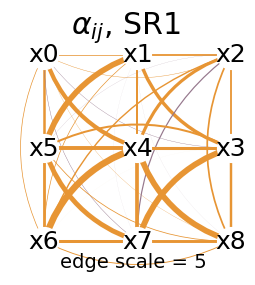

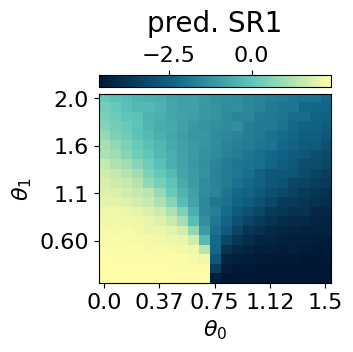

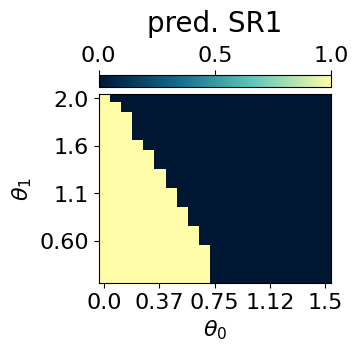

spearman between pred and exact corr:  0.9766054
auc:  0.9994868637110015


In [ ]:
## we then perform SR1 on the neel phase ##

mySR = SymbolicRegression(dataset, cluster_idx_in_neel, objective='SR1', search_space = "2_body_correlator")
key = jax.random.PRNGKey(3246)
res = mySR.train(key, dataset_size=2000)

## plot the alpha ##
topology = [[0,1,2],[5,4,3],[6,7,8]]
mySR.plot_alpha(topology=topology, edge_scale=5, name='SR1')


## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR1')
_ = mySR.compute_and_plot_prediction(name='SR1', class_pred=True)

## containers to save the results
all_alpha_neel = {}
all_alpha_neel['SR1'] = mySR.model.alpha
all_prediction_fx_neel = {}
all_prediction_fx_neel['SR1'] = p

## compute the spearman ##
#only on the left part of the parameter space where the Neel phase is
a = p[:,:10].transpose().reshape(-1)
c = all_data['corr_exact'][:10,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)

## compute the auc ##
scores = p.transpose()[:10,:].reshape(-1)
#for classification, we could use the final classification for the score: p>0. But it is unfair with the other SR which are not binary.
auc = auc_from_scores_labels(scores, labels_neel)

print('auc: ', auc)

The symbolic expression obtained using qdisc successfully **characterises the Néel phase**. It also have a quite regular structure which already give some insights about the physical interactions happening.

To have an even clearer structure, we can add a L1 regularization to the loss, as shown below.


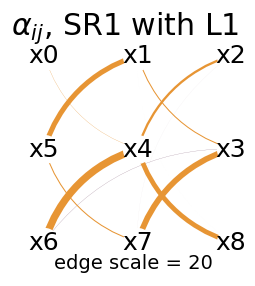

In [ ]:
res = mySR.train(key, dataset_size=2000, L1_reg=5, print_info=False)

mySR.plot_alpha(topology=topology, edge_scale=20, name='SR1 with L1')
all_alpha_neel['SR1_L1'] = mySR.model.alpha

This expression is especially insightful, as its structure naturally reflects the **topology and interactions of the system**.

An example of `qdisc.sr.SymbolicRegression()` using the **genetic search space** is available in the Rydberg example.

Using the **two-body correlator ansatz**, qdisc also allows further simplification of the learned coefficients $\alpha_{ij}$ into a **compact symbolic expression** by calling **PySR**. This can be done via the `.reduce_alpha()` method. An example of this workflow is presented in the cluster Ising example.

Below, we will apply the other SR objectives and also look for expressions characterizing the striped and polarised phases. This will reproduce the results presented in the paper. 

## Characterising the Néel phase with the other SR objectives

### SR2

### Start preparing the dataset ###
### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 4881.1623685647
        x: [ 2.200e-03  1.492e-01 ...  1.189e-01  1.828e+00]
      nit: 52
      jac: [-1.728e-03  6.457e-03 ...  4.457e-03 -2.910e-03]
     nfev: 2146
     njev: 58
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


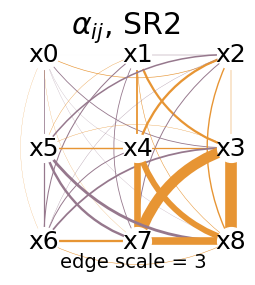

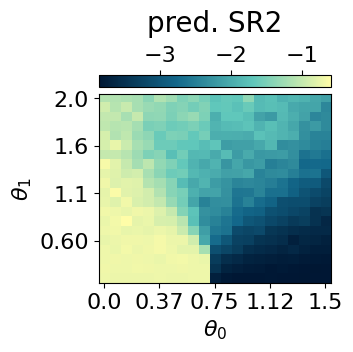

spearman between pred and exact corr:  0.8680327
auc:  0.9802955665024629


In [ ]:
## same but with the SR2 objective ##
mySR = SymbolicRegression(dataset,
                          cluster_idx_in_neel,
                          objective='SR2',
                          idx_mu_cluster=latvar['id_lat'][0],
                          VAE_model=VAE_model,
                          VAE_params=VAE_params,
                          mu_cluster = mu0abs.transpose())

key = jax.random.PRNGKey(456)
res = mySR.train(key)

## plot the alpha ##
topology = [[0,1,2],[5,4,3],[6,7,8]]
mySR.plot_alpha(topology=topology, edge_scale=3, name='SR2')


## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR2')

all_alpha_neel['SR2'] = mySR.model.alpha
all_prediction_fx_neel['SR2'] = p


## compute the spearman ##
a = p[:,:10].transpose().reshape(-1)
c = all_data['corr_exact'][:10,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)


## compute the auc ##
scores = p.transpose()[:10,:].reshape(-1)
auc = auc_from_scores_labels(scores, labels_neel)

print('auc: ', auc)

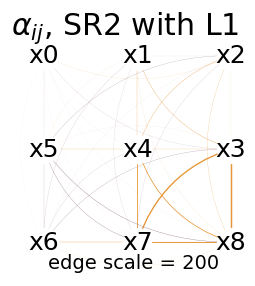

In [ ]:
## with L1 reg ##
res = mySR.train(key, dataset_size=2000, L1_reg=1, print_info=False)

mySR.plot_alpha(topology=topology, edge_scale=200, name='SR2 with L1')
all_alpha_neel['SR2_L1'] = mySR.model.alpha

### SR3

### Start preparing the dataset ###
small MLP training started...
step: 0, loss: 1.3135101195052237
step: 200, loss: 0.02557339298028621
step: 400, loss: 0.01930058812059929
step: 600, loss: 0.015483271911861551
step: 800, loss: 0.011208458239182977
step: 1000, loss: 0.00790998208938923
step: 1200, loss: 0.006366884336649446
step: 1400, loss: 0.005594927228562557
step: 1600, loss: 0.00513847305819626
step: 1800, loss: 0.004802868143484069
small MLP training finished!


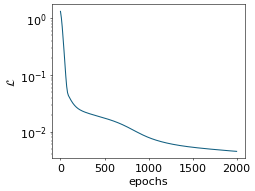

### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 4.741423295412271e-05
        x: [ 1.949e-01 -2.133e-01 ...  1.710e-01  1.932e-01]
      nit: 1
      jac: [-3.266e-06 -5.524e-07 ...  3.798e-06 -3.777e-06]
     nfev: 74
     njev: 2
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


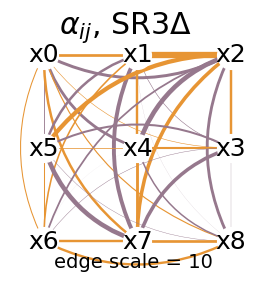

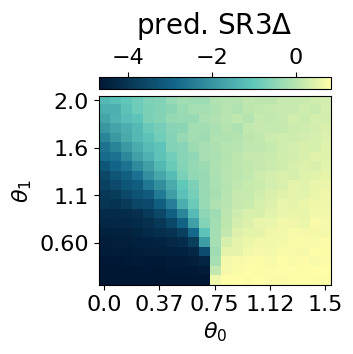

spearman between pred and exact corr:  0.9952689
auc:  0.9995894909688013


In [ ]:
## same but with the SR3 delta objective ##
mySR = SymbolicRegression(dataset, cluster_idx_in_neel, objective='SR3',
                                type_of_vk = 'delta',
                                idx_mu_cluster=latvar['id_lat'][0],
                                VAE_model=VAE_model,
                                VAE_params=VAE_params,
                                mu_cluster = mu0abs.transpose())
key = jax.random.PRNGKey(4352)
res = mySR.train(key)

## plot the alpha ##
mySR.plot_alpha(topology=topology, edge_scale=10, name=r'SR3$\Delta$')

## plot the prediction ##
p = mySR.compute_and_plot_prediction(name=r'SR3$\Delta$')

all_alpha_neel['SR3delta'] = mySR.model.alpha
all_prediction_fx_neel['SR3delta'] = p


## compute the spearman ##
a = p[:,:10].transpose().reshape(-1)
c = all_data['corr_exact'][:10,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)


## compute the auc ##
scores = p.transpose()[:10,:].reshape(-1)
auc = auc_from_scores_labels(scores, labels_neel)

print('auc: ', 1-auc)#grad matching doesnt impose <0 or >0 in the cluster, can just set what it has learned

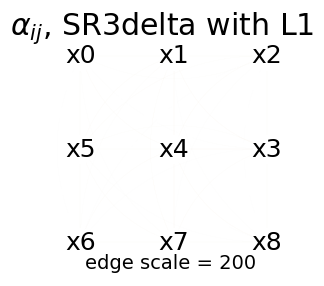

In [ ]:
# with L1 reg #
res = mySR.train(key, dataset_size=2000, L1_reg=0.001, print_info=False)

mySR.plot_alpha(topology=topology, edge_scale=200, name='SR3delta with L1')
all_alpha_neel['SR3delta_L1'] = mySR.model.alpha

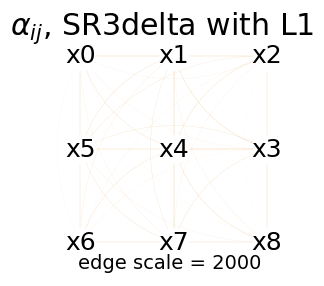

In [ ]:
#cannot sparse the alphas, just put all toward zero -> scale the edged more to see a bit the structure
mySR.plot_alpha(topology=topology, edge_scale=2000, name='SR3delta with L1')
all_alpha_neel['SR3delta_L1'] = mySR.model.alpha

### Start preparing the dataset ###
small MLP training started...
step: 0, loss: 0.8108281329182488
step: 200, loss: 0.022990639752391587
step: 400, loss: 0.018379645545828816
step: 600, loss: 0.013792992514905896
step: 800, loss: 0.007126792849677581
step: 1000, loss: 0.005054293962080803
step: 1200, loss: 0.004554070353060676
step: 1400, loss: 0.0041908284761713885
step: 1600, loss: 0.003924599748744378
step: 1800, loss: 0.0037443782009684433
small MLP training finished!


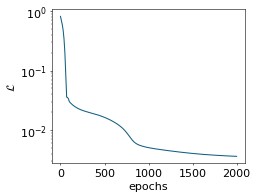

### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 3.028903275465175e-05
        x: [ 3.691e-02  2.518e-01 ...  3.132e-01  4.880e-02]
      nit: 3
      jac: [-1.199e-07 -1.170e-06 ...  2.010e-06 -1.214e-06]
     nfev: 148
     njev: 4
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


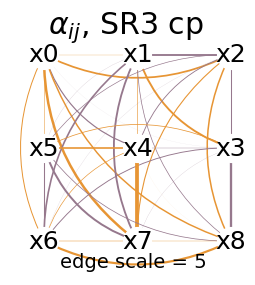

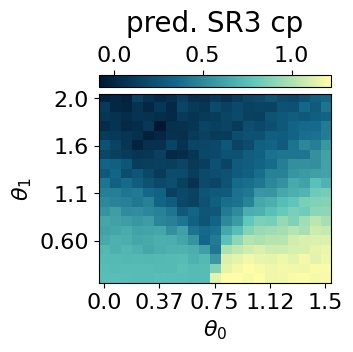

spearman between pred and exact corr:  0.8883972
auc:  0.0034893267651889825


In [ ]:
## same but with the SR3 cp objective ##
mySR = SymbolicRegression(dataset, cluster_idx_in_neel, objective='SR3',
                                type_of_vk = 'cp',
                                idx_mu_cluster=latvar['id_lat'][0],
                                VAE_model=VAE_model,
                                VAE_params=VAE_params,
                                mu_cluster = mu0abs.transpose())
key = jax.random.PRNGKey(78324)
res = mySR.train(key)

## plot the alpha ##
mySR.plot_alpha(topology=topology, edge_scale=5, name='SR3 cp')

## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR3 cp')

all_alpha_neel['SR3cp'] = mySR.model.alpha
all_prediction_fx_neel['SR3cp'] = p


## compute the spearman ##
a = p[:,:10].transpose().reshape(-1)#.reshape(10,-1)#all_prediction_neel_SR1[:,:10,:].reshape(10,-1)
c = all_data['corr_exact'][:10,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)


## compute the auc ##
scores = p.transpose()[:10,:].reshape(-1)
auc = auc_from_scores_labels(scores, labels_neel)

print('auc: ', 1-auc)

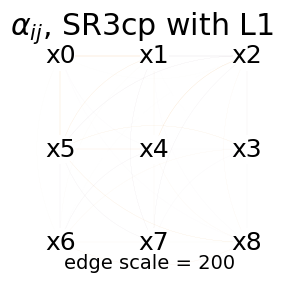

In [ ]:
# with L1 reg #
res = mySR.train(key, dataset_size=2000, L1_reg=0.001, print_info=False)

mySR.plot_alpha(topology=topology, edge_scale=200, name='SR3cp with L1')
all_alpha_neel['SR3cp_L1'] = mySR.model.alpha

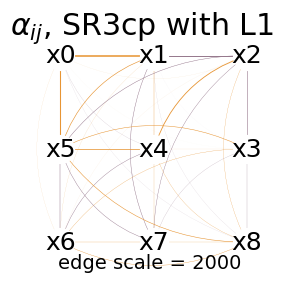

In [ ]:
mySR.plot_alpha(topology=topology, edge_scale=2000, name='SR3cp with L1')
all_alpha_neel['SR3cp_L1'] = mySR.model.alpha

## Characterising the Striped phase

Now we can do the same finding a symbolic function characterizing the striped phase. Here we will see that adding a L1 regularization can have significant impact on the structure of the optimal alpha

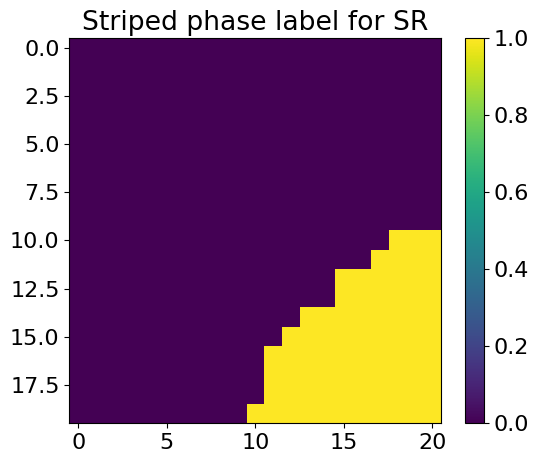

In [ ]:
threshold = 1.2
cluster_idx_in_striped = jnp.argwhere(mu0abs.transpose()>threshold)

labels_striped = jnp.zeros_like(jnp.mean(dataset.data, axis=(-1,-2)))
for id in cluster_idx_in_striped:
  labels_striped = labels_striped.at[id[0],id[1]].set(1)
labels_striped = labels_striped[10:,:].reshape(-1)

plt.rcParams['font.size'] = 16
plt.figure(figsize=(6,5),dpi=100)

plt.imshow(jnp.flipud(mu0abs>threshold), aspect='auto')
plt.colorbar()
plt.title(r'Striped phase label for SR')
plt.show()

### SR1

### Start preparing the dataset ###
### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 0.35385772926529285
        x: [ 2.416e-01  2.626e-01 ...  2.984e-01  5.520e-01]
      nit: 27
      jac: [ 1.138e-06 -2.831e-07 ...  1.443e-06  1.787e-06]
     nfev: 1147
     njev: 31
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


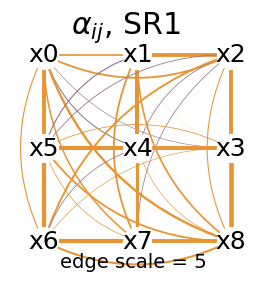

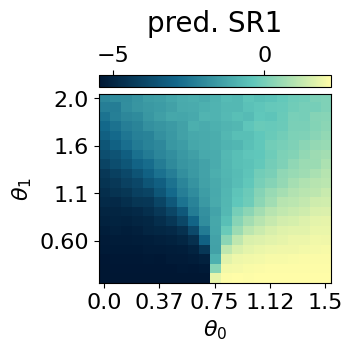

spearman between pred and exact corr:  0.9856973
auc:  0.9995459086368176


In [ ]:
## we then parform SR1 ##
mySR = SymbolicRegression(dataset, cluster_idx_in_striped, objective='SR1', search_space = "2_body_correlator")
key = jax.random.PRNGKey(451)
res = mySR.train(key, dataset_size=2000)

## plot the alpha ##
topology = [[0,1,2],[5,4,3],[6,7,8]]
mySR.plot_alpha(topology=topology, edge_scale=5, name='SR1')

## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR1')
#_ = mySR.compute_and_plot_prediction(name='SR1', class_pred=True)

## containers to save the results
all_alpha_striped = {}
all_alpha_striped['SR1'] = mySR.model.alpha
all_prediction_fx_striped = {}
all_prediction_fx_striped['SR1'] = p


## compute the spearman ##
#only on the left part of the parameter space where the Neel phase is
a = p[:,10:].transpose().reshape(-1)
c = all_data['corr2_exact'][10:,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)


## compute the auc ##
scores = p.transpose()[10:,:].reshape(-1)
auc = auc_from_scores_labels(scores, labels_striped)

print('auc: ', auc)

We see that the learned function successfully characterize the striped phase. However, what is coming out from the structure of the alpha is mostly the NN interactions. Only NN correlations is not enough to separate the striped phase from the polarized phase. Thus, the SR uses NN links to put negatives weights to the configuations coming from the Neel phase, but also uses other (smaller) links to separate the configurations of the striped phase with the one of the polarized phase. Having small links playing an important role motivates the use of the L1 regularization. It has the effect of making the structure of the alpha more sparse. 

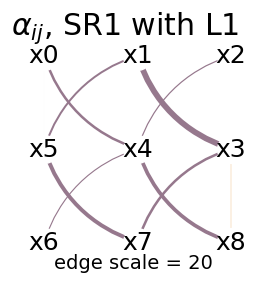

In [ ]:
res = mySR.train(key, dataset_size=2000, L1_reg=5, print_info=False)

mySR.plot_alpha(topology=topology, edge_scale=20, name='SR1 with L1')
all_alpha_striped['SR1_L1'] = mySR.model.alpha

Since with the L1 regularization, it is coslty to have small links, it has force the model to find another structure. The latter, only composed of NNN links, truely reflect the physics

### SR2

### Start preparing the dataset ###
### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 6112.24118796894
        x: [ 1.597e-02 -2.176e-02 ...  4.569e-01  4.823e+00]
      nit: 142
      jac: [ 3.750e+01 -6.173e+01 ... -3.012e+01  4.504e+01]
     nfev: 5920
     njev: 160
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


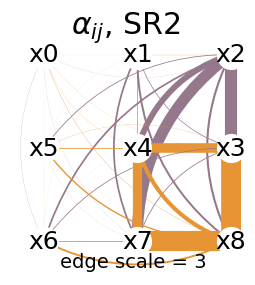

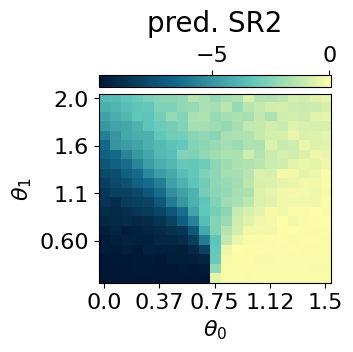

spearman between pred and exact corr:  0.9123445
auc:  0.9853782581055307


In [ ]:
## same but with the SR2 objective ##
mySR = SymbolicRegression(dataset,
                          cluster_idx_in_striped,
                          objective='SR2',
                          idx_mu_cluster=latvar['id_lat'][0],
                          VAE_model=VAE_model,
                          VAE_params=VAE_params,
                          mu_cluster = mu0abs.transpose())

key = jax.random.PRNGKey(4352)
res = mySR.train(key)

## plot the alpha ##
topology = [[0,1,2],[5,4,3],[6,7,8]]
mySR.plot_alpha(topology=topology, edge_scale=3, name='SR2')


## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR2')


all_alpha_striped['SR2'] = mySR.model.alpha
all_prediction_fx_striped['SR2'] = p

## compute the spearman ##
a = p[:,10:].transpose().reshape(-1)
c = all_data['corr2_exact'][10:,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)

## compute the auc ##
scores = p.transpose()[10:,:].reshape(-1)
auc = auc_from_scores_labels(scores, labels_striped)

print('auc: ', auc)

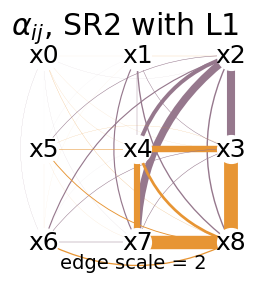

In [ ]:
res = mySR.train(key, dataset_size=2000, L1_reg=5, print_info=False)

mySR.plot_alpha(topology=topology, edge_scale=2, name='SR2 with L1')
all_alpha_striped['SR2_L1'] = mySR.model.alpha

### SR3

### Start preparing the dataset ###
small MLP training started...
step: 0, loss: 0.8306435624033267
step: 200, loss: 0.022729998733001314
step: 400, loss: 0.012853822483299545
step: 600, loss: 0.009001298929735141
step: 800, loss: 0.006472594732634401
step: 1000, loss: 0.0053942774443079475
step: 1200, loss: 0.004843800840597344
step: 1400, loss: 0.004416942913320327
step: 1600, loss: 0.004095027750714443
step: 1800, loss: 0.0038483704481203193
small MLP training finished!


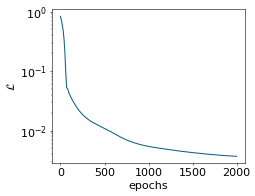

### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 5.033572095590647e-05
        x: [ 1.583e-01 -3.731e-01 ... -2.044e-01  1.133e-01]
      nit: 1
      jac: [-1.883e-07 -1.702e-06 ... -1.041e-06 -6.664e-07]
     nfev: 74
     njev: 2
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


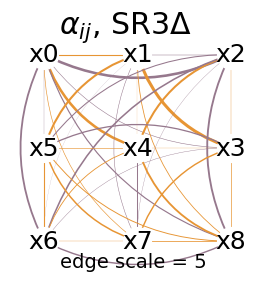

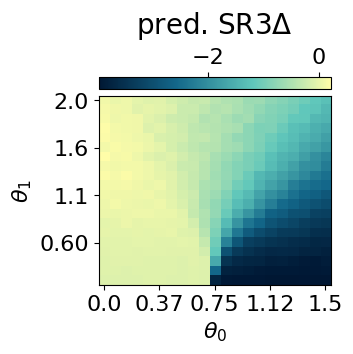

spearman between pred and exact corr:  0.9957388
auc:  0.9999091817273635


In [ ]:
## same but with the SR3 delta objective ##
mySR = SymbolicRegression(dataset, cluster_idx_in_striped, objective='SR3',
                                type_of_vk = 'delta',
                                idx_mu_cluster=latvar['id_lat'][0],
                                VAE_model=VAE_model,
                                VAE_params=VAE_params,
                                mu_cluster = mu0abs.transpose())
key = jax.random.PRNGKey(43)
res = mySR.train(key)

## plot the alpha ##
mySR.plot_alpha(topology=topology, edge_scale=5, name=r'SR3$\Delta$')

## plot the prediction ##
p = mySR.compute_and_plot_prediction(name=r'SR3$\Delta$')

all_alpha_striped['SR3delta'] = mySR.model.alpha
all_prediction_fx_striped['SR3delta'] = p

## compute the spearman ##
a = p[:,10:].transpose().reshape(-1)
c = all_data['corr2_exact'][10:,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)

## compute the auc ##
scores = p.transpose()[10:,:].reshape(-1)
auc = auc_from_scores_labels(scores, labels_striped)

print('auc: ', 1-auc)

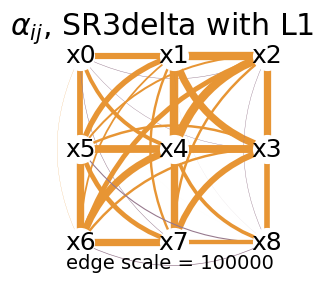

In [ ]:
res = mySR.train(key, dataset_size=2000, L1_reg=0.001, print_info=False)

mySR.plot_alpha(topology=topology, edge_scale=100000, name='SR3delta with L1')
all_alpha_striped['SR3delta_L1'] = mySR.model.alpha

### Start preparing the dataset ###
small MLP training started...
step: 0, loss: 1.0204663818001058
step: 200, loss: 0.022198006678656765
step: 400, loss: 0.015752300675528446
step: 600, loss: 0.008494966136517072
step: 800, loss: 0.006575532075133302
step: 1000, loss: 0.005692395010923643
step: 1200, loss: 0.005104944107537137
step: 1400, loss: 0.0046760973153922285
step: 1600, loss: 0.004366116851316101
step: 1800, loss: 0.00415812396293911
small MLP training finished!


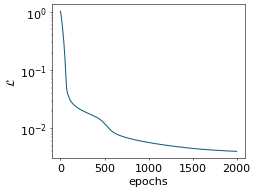

### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 3.6736764372466765e-05
        x: [ 3.881e-02 -8.508e-02 ...  4.114e-01 -4.009e-02]
      nit: 2
      jac: [-6.732e-07 -2.398e-07 ... -6.565e-07  2.584e-06]
     nfev: 111
     njev: 3
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


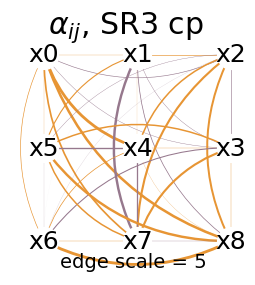

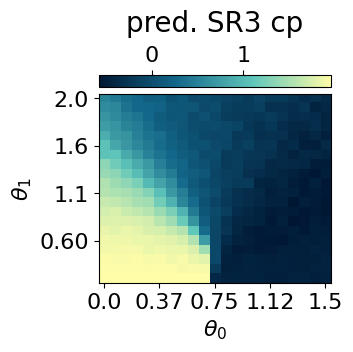

spearman between pred and exact corr:  0.8544463
auc:  0.9323403868858414


In [ ]:
## same but with the SR3 cp objective ##
mySR = SymbolicRegression(dataset, cluster_idx_in_striped, objective='SR3',
                                type_of_vk = 'cp',
                                idx_mu_cluster=latvar['id_lat'][0],
                                VAE_model=VAE_model,
                                VAE_params=VAE_params,
                                mu_cluster = mu0abs.transpose())
key = jax.random.PRNGKey(11122)
model = mySR.train(key)

## plot the alpha ##
mySR.plot_alpha(topology=topology, edge_scale=5, name='SR3 cp')

## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR3 cp')

all_alpha_striped['SR3cp'] = mySR.model.alpha
all_prediction_fx_striped['SR3cp'] = p

## compute the spearman ##
a = p[:,10:].transpose().reshape(-1)
c = all_data['corr2_exact'][10:,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)


## compute the auc ##
scores = p.transpose()[10:,:].reshape(-1)
auc = auc_from_scores_labels(scores, labels_striped)

print('auc: ', 1-auc)

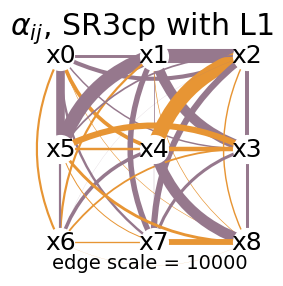

In [ ]:
res = mySR.train(key, dataset_size=2000, L1_reg=0.001, print_info=False)

mySR.plot_alpha(topology=topology, edge_scale=10000, name='SR3cp with L1')
all_alpha_striped['SR3cp_L1'] = mySR.model.alpha

## Characterising the polarized phase

Finally, we use the symbolic method to find a function characterizing the Polarized phase, or, equivalently, both Neel and striped phase from the rest.

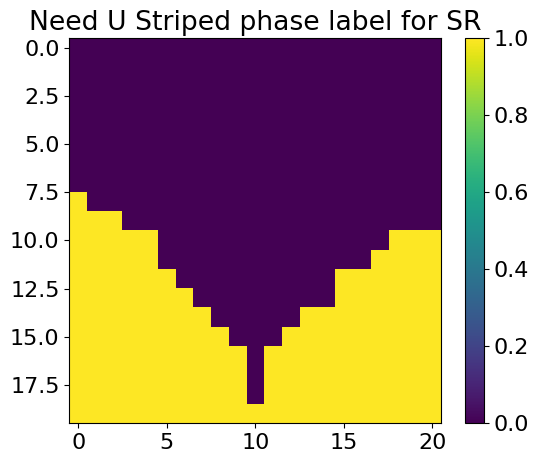

In [ ]:
threshold = 1.2
cluster_idx_in_both = jnp.argwhere(((mu0abs<threshold)*1 + (mu0abs<0.5)*1).transpose()!=1)

labels_both = jnp.zeros_like(jnp.mean(dataset.data, axis=(-1,-2)))
for id in cluster_idx_in_both:
  labels_both = labels_both.at[id[0],id[1]].set(1)
labels_both = labels_both[:,:].reshape(-1)


plt.rcParams['font.size'] = 16
plt.figure(figsize=(6,5),dpi=100)

plt.imshow(jnp.flipud(((mu0abs<threshold)*1 + (mu0abs<0.5)*1)!=1), aspect='auto')
plt.colorbar()
plt.title(r'Need U Striped phase label for SR')
plt.show()

### SR1

### Start preparing the dataset ###
### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 0.5392219078205132
        x: [ 2.660e-01  1.081e-01 ...  3.508e-01  3.615e-01]
      nit: 26
      jac: [-8.993e-07  3.497e-06 ...  2.354e-06  6.439e-07]
     nfev: 1184
     njev: 32
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


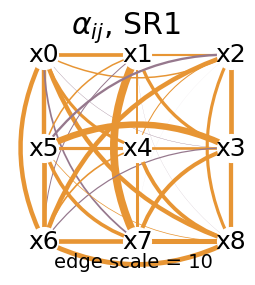

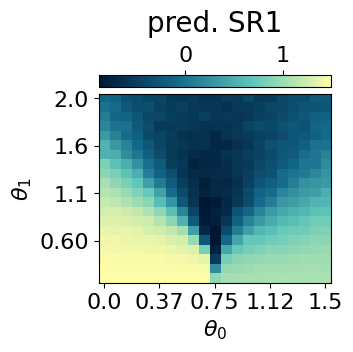

spearman between pred and exact corr:  0.94364965
auc:  0.9939087268279815


In [ ]:
## we then parform SR1 ##
mySR = SymbolicRegression(dataset, cluster_idx_in_both, objective='SR1', search_space = "2_body_correlator" )
key = jax.random.PRNGKey(432)
res = mySR.train(key, dataset_size=2000)

## plot the alpha ##
topology = [[0,1,2],[5,4,3],[6,7,8]]
mySR.plot_alpha(topology=topology, edge_scale=10, name='SR1')

## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR1')

## containers to safe the results
all_alpha_both = {}
all_alpha_both['SR1'] = mySR.model.alpha
all_prediction_fx_both = {}
all_prediction_fx_both['SR1'] = p


## compute the spearman ##
#only on the left part of the parameter space where the Neel phase is
a = p[:,:].transpose().reshape(-1)
c = jnp.abs(all_data['corr2_exact'])[:,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)

## compute the auc ##
scores = p.transpose().reshape(-1)
auc = auc_from_scores_labels(scores, labels_both)

print('auc: ', auc)

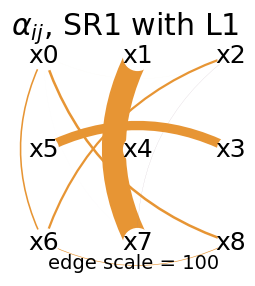

In [ ]:
res = mySR.train(key, dataset_size=2000, L1_reg=5, print_info=False)

mySR.plot_alpha(topology=topology, edge_scale=100, name='SR1 with L1')
all_alpha_both['SR1_L1'] = mySR.model.alpha

With the spins being aligned in the x directions, the polarized case dont have a nice structure in the measurement basis. Thus, the structure of the function characterizing this phase is not very nice

### SR2

### Start preparing the dataset ###
### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 10732.869753169098
        x: [ 8.631e-03 -5.888e-03 ...  6.422e-02  1.905e+00]
      nit: 99
      jac: [-9.387e+02  2.210e+03 ... -1.967e+03  1.093e+02]
     nfev: 7474
     njev: 202
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


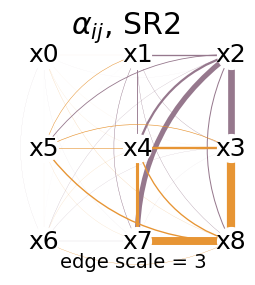

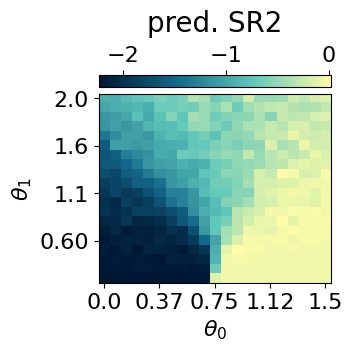

spearman between pred and exact corr:  0.0026733226
auc:  0.4688361831218974


In [ ]:
## same but with the SR2 objective ##
mySR = SymbolicRegression(dataset,
                          cluster_idx_in_both,
                          objective='SR2',
                          idx_mu_cluster=latvar['id_lat'][0],
                          VAE_model=VAE_model,
                          VAE_params=VAE_params,
                          mu_cluster = mu0abs.transpose())

key = jax.random.PRNGKey(996)
res = mySR.train(key)

## plot the alpha ##
topology = [[0,1,2],[5,4,3],[6,7,8]]
mySR.plot_alpha(topology=topology, edge_scale=3, name='SR2')


## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR2')


all_alpha_both['SR2'] = mySR.model.alpha
all_prediction_fx_both['SR2'] = p

## compute the spearman ##
a = p[:,:].transpose().reshape(-1)
c = jnp.abs(all_data['corr2_exact'])[:,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)

## compute the auc ##
scores = p.transpose().reshape(-1)
auc = auc_from_scores_labels(scores, labels_both)

print('auc: ', auc)

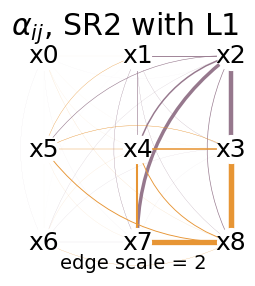

In [ ]:
res = mySR.train(key, dataset_size=2000, L1_reg=10, print_info=False)

mySR.plot_alpha(topology=topology, edge_scale=2, name='SR2 with L1')
all_alpha_both['SR2_L1'] = mySR.model.alpha

### SR3

### Start preparing the dataset ###
small MLP training started...
step: 0, loss: 1.5711885593078965
step: 200, loss: 0.029661849174511697
step: 400, loss: 0.019414914643345688
step: 600, loss: 0.01446558024228287
step: 800, loss: 0.011838310234110156
step: 1000, loss: 0.010241172457702667
step: 1200, loss: 0.008904530822363583
step: 1400, loss: 0.007550049233107614
step: 1600, loss: 0.006433031709706265
step: 1800, loss: 0.005693161142466824
small MLP training finished!


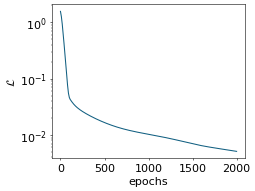

### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 2.616992265663539e-05
        x: [ 6.206e-02 -3.043e-01 ... -2.726e-01 -5.906e-03]
      nit: 2
      jac: [-1.459e-06  1.605e-08 ... -2.588e-07 -7.735e-07]
     nfev: 111
     njev: 3
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


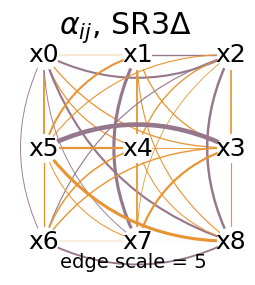

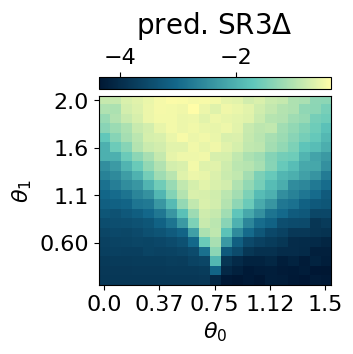

spearman between pred and exact corr:  0.9798321
auc:  0.9979136190316314


In [ ]:
## same but with the SR3 delta objective ##
mySR = SymbolicRegression(dataset, cluster_idx_in_both, objective='SR3',
                                type_of_vk = 'delta',
                                idx_mu_cluster=latvar['id_lat'][0],
                                VAE_model=VAE_model,
                                VAE_params=VAE_params,
                                mu_cluster = mu0abs.transpose())
key = jax.random.PRNGKey(439)
res = mySR.train(key)

## plot the alpha ##
mySR.plot_alpha(topology=topology, edge_scale=5, name=r'SR3$\Delta$')

## plot the prediction ##
p = mySR.compute_and_plot_prediction(name=r'SR3$\Delta$')

all_alpha_both['SR3delta'] = mySR.model.alpha
all_prediction_fx_both['SR3delta'] = p

## compute the spearman ##
a = p[:,:].transpose().reshape(-1)
c = jnp.abs(all_data['corr2_exact'])[:,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)

## compute the auc ##
scores = p.transpose().reshape(-1)
auc = auc_from_scores_labels(scores, labels_both)

print('auc: ', 1-auc)

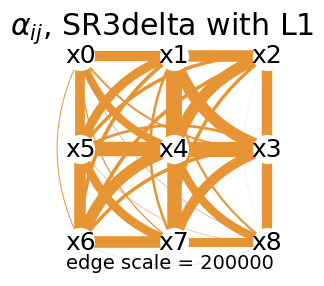

In [ ]:
res = mySR.train(key, dataset_size=2000, L1_reg=0.001, print_info=False)

mySR.plot_alpha(topology=topology, edge_scale=200000, name='SR3delta with L1')
all_alpha_both['SR3delta_L1'] = mySR.model.alpha

### Start preparing the dataset ###
small MLP training started...
step: 0, loss: 0.8257745814735783
step: 200, loss: 0.01860260827326228
step: 400, loss: 0.011823513169308493
step: 600, loss: 0.007060975685731395
step: 800, loss: 0.00489831556162105
step: 1000, loss: 0.004153469428332058
step: 1200, loss: 0.0037614909812640936
step: 1400, loss: 0.0035468095783897195
step: 1600, loss: 0.0034031894757354936
step: 1800, loss: 0.0032945502351812675
small MLP training finished!


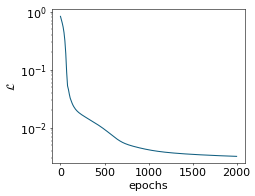

### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 2.5508192516536702e-05
        x: [ 9.475e-03  1.658e-01 ...  5.183e-01  1.482e-01]
      nit: 1
      jac: [-5.482e-07  8.301e-07 ...  5.014e-06 -3.561e-06]
     nfev: 74
     njev: 2
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


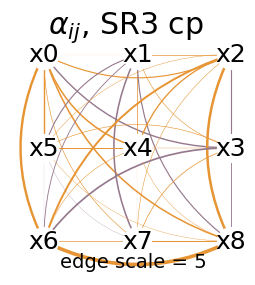

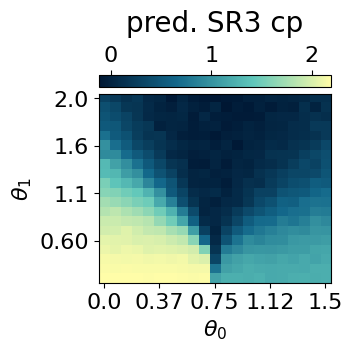

spearman between pred and exact corr:  0.9045025
auc:  0.9791841530971965


In [ ]:
## same but with the SR3 cp objective ##
mySR = SymbolicRegression(dataset, cluster_idx_in_both, objective='SR3',
                                type_of_vk = 'cp',
                                idx_mu_cluster=latvar['id_lat'][0],
                                VAE_model=VAE_model,
                                VAE_params=VAE_params,
                                mu_cluster = mu0abs.transpose())
key = jax.random.PRNGKey(54631)
model = mySR.train(key)

## plot the alpha ##
mySR.plot_alpha(topology=topology, edge_scale=5, name='SR3 cp')

## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR3 cp')

all_alpha_both['SR3cp'] = mySR.model.alpha
all_prediction_fx_both['SR3cp'] = p

## compute the spearman ##
a = p[:,:].transpose().reshape(-1)
c = jnp.abs(all_data['corr2_exact'])[:,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)

## compute the auc ##
scores = p.transpose().reshape(-1)
auc = auc_from_scores_labels(scores, labels_both)

print('auc: ', auc)

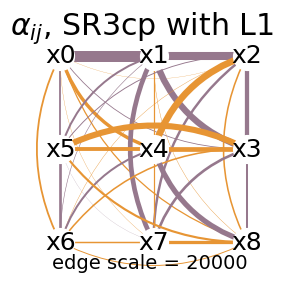

In [ ]:
res = mySR.train(key, dataset_size=2000, L1_reg=0.001, print_info=False)

mySR.plot_alpha(topology=topology, edge_scale=20000, name='SR3cp with L1')
all_alpha_both['SR3cp_L1'] = mySR.model.alpha

In [ ]:
## also add the data and the exact corr ##

all_data['alpha_neel'] = all_alpha_neel
all_data['prediction_fx_neel'] = all_prediction_fx_neel
all_data['alpha_striped'] = all_alpha_striped
all_data['prediction_fx_striped'] = all_prediction_fx_striped
all_data['alpha_both'] = all_alpha_both
all_data['prediction_fx_both'] = all_prediction_fx_both


small MLP training started...
step: 0, loss: 0.9165100857669783
step: 200, loss: 0.023040097177329327
step: 400, loss: 0.018953575042534948
step: 600, loss: 0.014705703456012941
step: 800, loss: 0.009733298547767298
step: 1000, loss: 0.006713810330803795
step: 1200, loss: 0.005106953388377555
step: 1400, loss: 0.0045086195023626464
step: 1600, loss: 0.0041721548633482375
step: 1800, loss: 0.0039043747535851977
small MLP training finished!


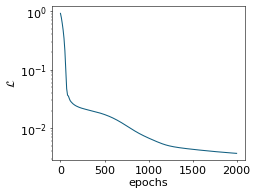

In [ ]:
## plus some other values needed for some plots
mySR = SymbolicRegression(dataset, cluster_idx_in_neel, objective='SR3',
                                type_of_vk = 'delta',
                                idx_mu_cluster=latvar['id_lat'][0],
                                VAE_model=VAE_model,
                                VAE_params=VAE_params,
                                mu_cluster = mu0abs.transpose())
key = jax.random.PRNGKey(89)
G = mySR.get_grad_mu_wrt_theta_SR3(key, cluster_idx_in_neel)
all_data['grad_mu1_neel_boundaries'] = G

In [ ]:
with open('J1J2_data_cpVAE2_QDisc.pkl', 'wb') as f:
    pickle.dump(all_data, f)

## Challenging the robustness of SR1

We will now test the robustness of SR1 with respect to changes in the 'in' and 'out' labels in its dataset. To achieve this, we will apply Gaussian noise to the 'true' labels used above. This results in 'out' data being labelled as 'in' and vice versa. We will then observe the effect on the structure of the learned expression, as well as on the various performance metrics.  
Both with and without a L1 regularization will be considered.

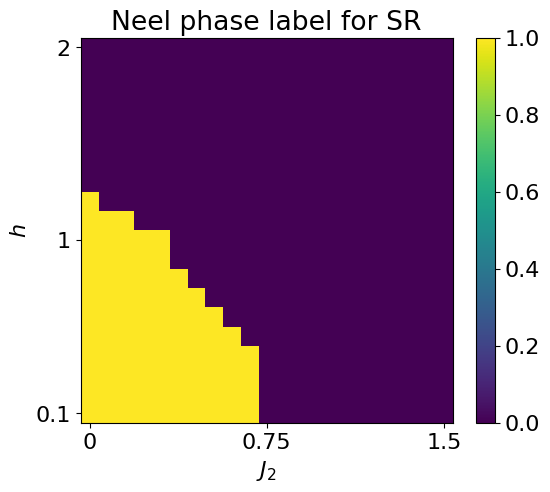

In [ ]:
## 'True' labels used above ##
mu0abs = latvar['mu0_abs']
threshold = 0.5
cluster_idx_in_neel = jnp.argwhere(mu0abs.transpose()<threshold)

labels_neel = jnp.zeros_like(jnp.mean(dataset.data, axis=(-1,-2)))
for id in cluster_idx_in_neel:
  labels_neel = labels_neel.at[id[0],id[1]].set(1)
labels_neel = labels_neel[:10,:].reshape(-1)

plt.rcParams['font.size'] = 16
plt.figure(figsize=(6,5),dpi=100)

plt.imshow(jnp.flipud(mu0abs<threshold), aspect='auto')
plt.colorbar()
plt.title(r'Neel phase label for SR')
plt.yticks([0,10,19], ['2', '1', '0.1'])
plt.xticks([0, 10, 20], ['0', '0.75', '1.5'])
plt.ylabel(r'$h$')
plt.xlabel(r'$J_2$')
plt.show()

### without L1

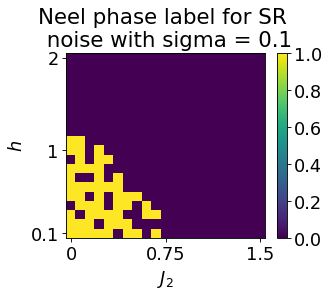

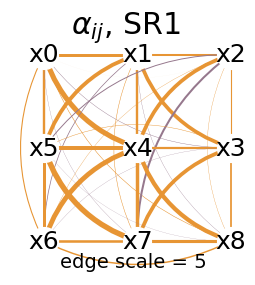

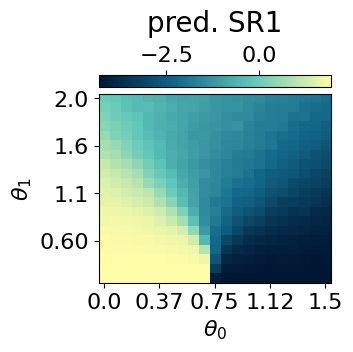

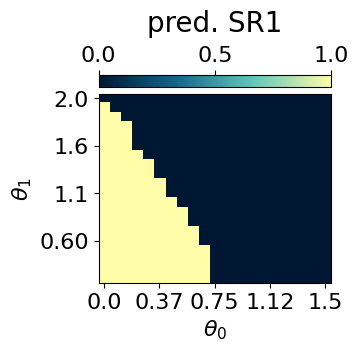

In in in: 100.00%, in in out: 0.00%, out in in: 8.20%, out in out: 91.80%, s=0.9739, auc=0.9993
In in in: 100.00%, in in out: 0.00%, out in in: 7.95%, out in out: 92.05%, s=0.9737, auc=0.9992
In in in: 100.00%, in in out: 0.00%, out in in: 9.92%, out in out: 90.08%, s=0.9700, auc=0.9989
In in in: 100.00%, in in out: 0.00%, out in in: 8.20%, out in out: 91.80%, s=0.9736, auc=0.9993
In in in: 100.00%, in in out: 0.00%, out in in: 8.94%, out in out: 91.06%, s=0.9714, auc=0.9991
In in in: 100.00%, in in out: 0.00%, out in in: 6.67%, out in out: 93.33%, s=0.9726, auc=0.9989
In in in: 100.00%, in in out: 0.00%, out in in: 7.69%, out in out: 92.31%, s=0.9717, auc=0.9992
In in in: 100.00%, in in out: 0.00%, out in in: 7.69%, out in out: 92.31%, s=0.9725, auc=0.9992
In in in: 100.00%, in in out: 0.00%, out in in: 7.44%, out in out: 92.56%, s=0.9730, auc=0.9993
In in in: 100.00%, in in out: 0.00%, out in in: 7.44%, out in out: 92.56%, s=0.9724, auc=0.9996


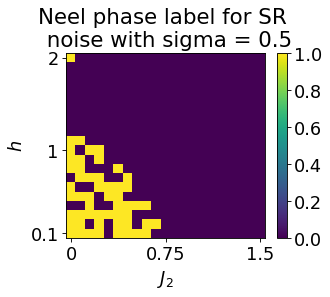

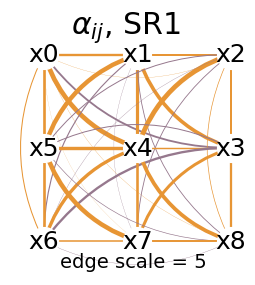

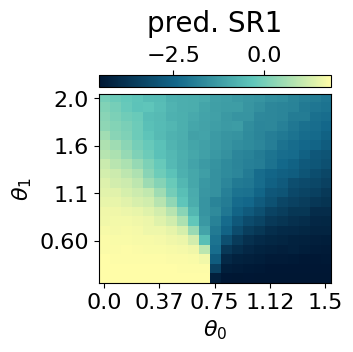

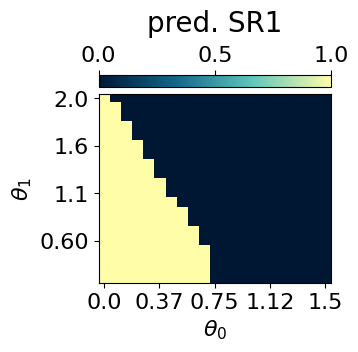

In in in: 98.11%, in in out: 1.89%, out in in: 8.72%, out in out: 91.28%, s=0.9736, auc=0.9994
In in in: 98.18%, in in out: 1.82%, out in in: 8.22%, out in out: 91.78%, s=0.9739, auc=0.9994
In in in: 98.39%, in in out: 1.61%, out in in: 6.42%, out in out: 93.58%, s=0.9748, auc=0.9995
In in in: 98.33%, in in out: 1.67%, out in in: 6.94%, out in out: 93.06%, s=0.9739, auc=0.9994
In in in: 100.00%, in in out: 0.00%, out in in: 8.20%, out in out: 91.80%, s=0.9733, auc=0.9994
In in in: 100.00%, in in out: 0.00%, out in in: 8.45%, out in out: 91.55%, s=0.9717, auc=0.9990
In in in: 100.00%, in in out: 0.00%, out in in: 8.20%, out in out: 91.80%, s=0.9733, auc=0.9993
In in in: 96.00%, in in out: 4.00%, out in in: 9.73%, out in out: 90.27%, s=0.9735, auc=0.9995
In in in: 100.00%, in in out: 0.00%, out in in: 8.45%, out in out: 91.55%, s=0.9722, auc=0.9995
In in in: 96.72%, in in out: 3.28%, out in in: 6.96%, out in out: 93.04%, s=0.9753, auc=0.9995


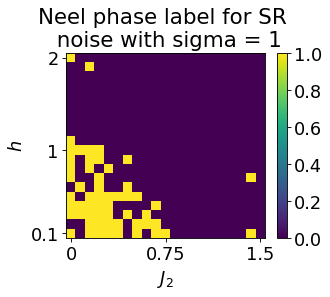

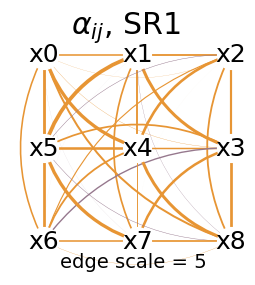

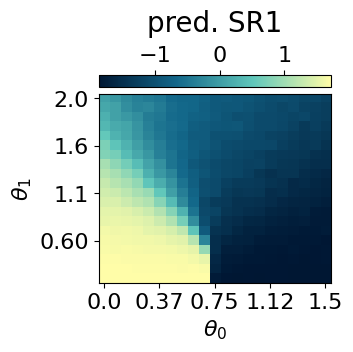

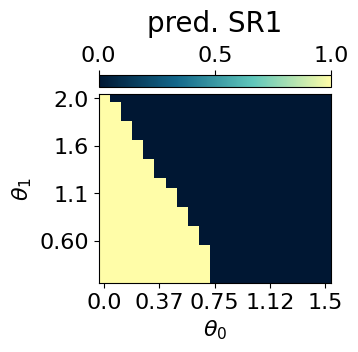

In in in: 89.29%, in in out: 10.71%, out in in: 9.34%, out in out: 90.66%, s=0.9738, auc=0.9996
In in in: 85.96%, in in out: 14.04%, out in in: 9.64%, out in out: 90.36%, s=0.9785, auc=0.9996
In in in: 91.23%, in in out: 8.77%, out in in: 8.82%, out in out: 91.18%, s=0.9752, auc=0.9995
In in in: 80.65%, in in out: 19.35%, out in in: 9.50%, out in out: 90.50%, s=0.9760, auc=0.9994
In in in: 89.29%, in in out: 10.71%, out in in: 9.34%, out in out: 90.66%, s=0.9749, auc=0.9994
In in in: 94.74%, in in out: 5.26%, out in in: 8.26%, out in out: 91.74%, s=0.9754, auc=0.9995
In in in: 91.07%, in in out: 8.93%, out in in: 9.07%, out in out: 90.93%, s=0.9736, auc=0.9996
In in in: 90.20%, in in out: 9.80%, out in in: 10.30%, out in out: 89.70%, s=0.9732, auc=0.9996
In in in: 92.16%, in in out: 7.84%, out in in: 10.03%, out in out: 89.97%, s=0.9763, auc=0.9995
In in in: 87.50%, in in out: 12.50%, out in in: 9.62%, out in out: 90.38%, s=0.9763, auc=0.9994


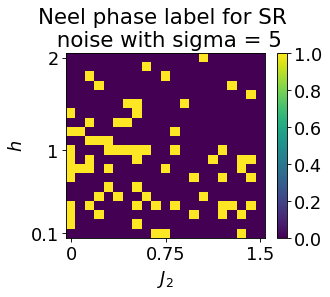

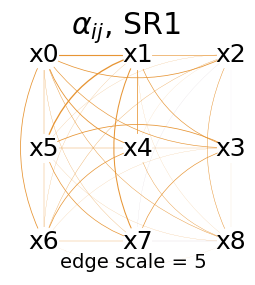

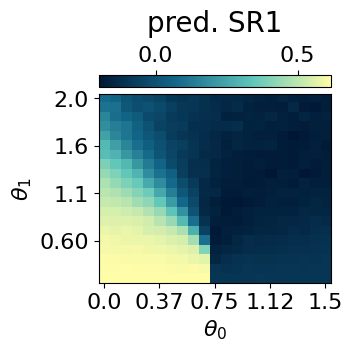

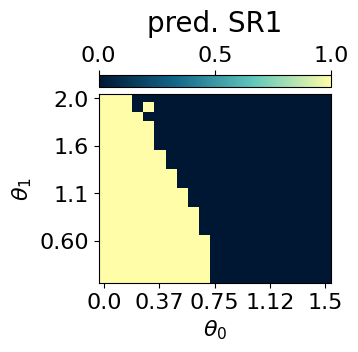

In in in: 34.72%, in in out: 65.28%, out in in: 16.81%, out in out: 83.19%, s=0.9857, auc=0.9997
In in in: 41.67%, in in out: 58.33%, out in in: 15.47%, out in out: 84.53%, s=0.9859, auc=0.9997
In in in: 32.88%, in in out: 67.12%, out in in: 17.24%, out in out: 82.76%, s=0.9876, auc=0.9996
In in in: 39.47%, in in out: 60.53%, out in in: 16.43%, out in out: 83.57%, s=0.9824, auc=0.9996
In in in: 38.75%, in in out: 61.25%, out in in: 15.54%, out in out: 84.46%, s=0.9783, auc=0.9998
In in in: 44.00%, in in out: 56.00%, out in in: 14.78%, out in out: 85.22%, s=0.9842, auc=0.9995
In in in: 41.03%, in in out: 58.97%, out in in: 15.12%, out in out: 84.88%, s=0.9836, auc=0.9993
In in in: 40.85%, in in out: 59.15%, out in in: 15.76%, out in out: 84.24%, s=0.9854, auc=0.9995
In in in: 41.43%, in in out: 58.57%, out in in: 15.62%, out in out: 84.38%, s=0.9835, auc=0.9995
In in in: 41.10%, in in out: 58.90%, out in in: 15.52%, out in out: 84.48%, s=0.9836, auc=0.9995


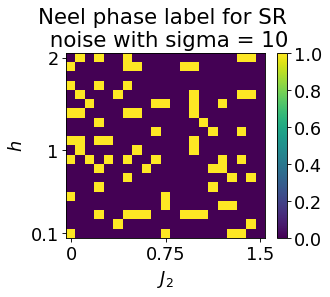

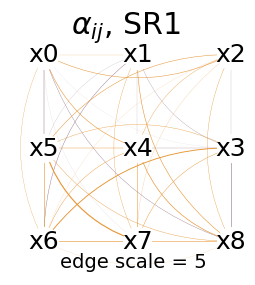

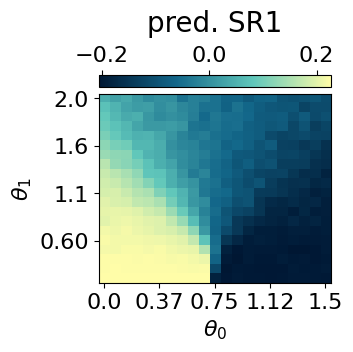

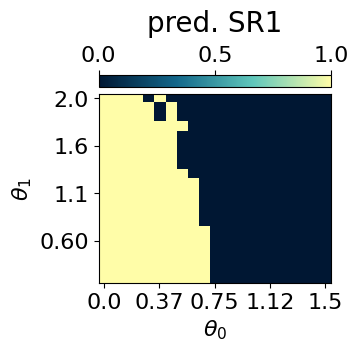

In in in: 23.17%, in in out: 76.83%, out in in: 19.71%, out in out: 80.29%, s=0.9892, auc=0.9992
In in in: 23.75%, in in out: 76.25%, out in in: 19.30%, out in out: 80.70%, s=0.8090, auc=0.9910
In in in: 19.48%, in in out: 80.52%, out in in: 20.06%, out in out: 79.94%, s=0.1259, auc=0.5974
In in in: 27.85%, in in out: 72.15%, out in in: 18.39%, out in out: 81.61%, s=0.9788, auc=0.9993
In in in: 18.07%, in in out: 81.93%, out in in: 19.94%, out in out: 80.06%, s=0.8441, auc=0.9984
In in in: 33.33%, in in out: 66.67%, out in in: 16.95%, out in out: 83.05%, s=0.9916, auc=0.9996
In in in: 24.36%, in in out: 75.64%, out in in: 18.84%, out in out: 81.16%, s=0.9681, auc=0.9985
In in in: 25.93%, in in out: 74.07%, out in in: 19.13%, out in out: 80.87%, s=0.9937, auc=0.9999
In in in: 27.16%, in in out: 72.84%, out in in: 18.55%, out in out: 81.45%, s=0.9821, auc=0.9993
In in in: 27.16%, in in out: 72.84%, out in in: 18.21%, out in out: 81.79%, s=0.9833, auc=0.9994


In [ ]:
cluster_idx_in_neel = jnp.argwhere(mu0abs.transpose()<threshold)
c = all_data['corr_exact'][:10,:].reshape(-1)
labels_neel = jnp.zeros_like(jnp.mean(dataset.data, axis=(-1,-2)))
for id in cluster_idx_in_neel:
  labels_neel = labels_neel.at[id[0],id[1]].set(1)   
labels_neel = labels_neel[:10,:].reshape(-1)

topology = [[0,1,2],[5,4,3],[6,7,8]]

key = jax.random.PRNGKey(534)

all_spearman_SR1 = []
all_auc_SR1 = []
all_alpha_SR1 = []
example_labels = []
example_pred = []
all_percentage_in_in_in_label = []
all_percentage_in_in_out_label = []
all_percentage_out_in_in_label = []
all_percentage_out_in_out_label = []


for sigma in [0.1, 0.5, 1, 5, 10]:
    all_s = []
    all_auc = []
    all_alpha = []
    percentage_in_in_in_label = []
    percentage_in_in_out_label = []
    percentage_out_in_in_label = []
    percentage_out_in_out_label = []
    l1 = 0
    for i in range(10):
                  
        key, subkey = jax.random.split(key)
        cluster_idx_in_neel_noisy = cluster_idx_in_neel + sigma*jax.random.normal(subkey, jnp.shape(cluster_idx_in_neel))
        cluster_idx_in_neel_noisy = cluster_idx_in_neel_noisy.astype(jnp.int64)
        #remove duplicate
        cluster_idx_in_neel_noisy = jnp.array(list(set([tuple(idx.tolist()) for idx in cluster_idx_in_neel_noisy])))
        #keep inside
        cluster_idx_in_neel_noisy = cluster_idx_in_neel_noisy%20
        
        if i == 0:
            labels_neel_noisy = jnp.zeros_like(jnp.mean(dataset.data, axis=(-1,-2)))
            for id in cluster_idx_in_neel_noisy:
              labels_neel_noisy = labels_neel_noisy.at[id[0],id[1]].set(1)   
            example_labels.append(labels_neel_noisy)
            
            plt.rcParams['font.size'] = 16
            plt.figure(figsize=(4,3),dpi=80)
            
            plt.imshow(jnp.rot90(labels_neel_noisy), aspect='auto')
            plt.colorbar()
            plt.title('Neel phase label for SR \n noise with sigma = {}'.format(sigma))
            plt.yticks([0,10,19], ['2', '1', '0.1'])
            plt.xticks([0, 10, 20], ['0', '0.75', '1.5'])
            plt.ylabel(r'$h$')
            plt.xlabel(r'$J_2$')
            plt.show()
        
    
        ## perform SR1 on the neel phase ##
    
        mySR = SymbolicRegression(dataset, cluster_idx_in_neel_noisy, objective='SR1', search_space = "2_body_correlator")
        key, subkey = jax.random.split(key)
        res = mySR.train(subkey, dataset_size=2000, print_info = False)
    
        all_alpha.append(mySR.model.alpha)
        if i == 0:
            mySR.plot_alpha(topology=topology, edge_scale=5, name='SR1')
        
        if i == 0:
            p = mySR.compute_and_plot_prediction(name='SR1')
            _ = mySR.compute_and_plot_prediction(name='SR1', class_pred=True)
            example_pred.append(p)
        else:
            p = mySR.compute_prediction()
        a = p[:,:10].transpose().reshape(-1)
        s = jnp.abs(spearman_rho(a, c))
        
        all_s.append(s)
        
        scores = p.transpose()[:10,:].reshape(-1)
        auc = auc_from_scores_labels(scores, labels_neel)

        if auc < 0.5:
            auc = 1 - auc
        
        all_auc.append(auc)
      

        parameter_space_shape = [len(dataset.thetas[i]) for i in range(len(dataset.thetas))]
        grid = jnp.indices(parameter_space_shape)      # (k, ...)
        grid = grid.reshape(len(parameter_space_shape), -1).T  # (N, k)
        equal = jnp.all(grid[:, None, :] == cluster_idx_in_neel[None, :, :], axis=-1)
        in_cluster = jnp.any(equal, axis=1)
        cluster_idx_out_neel = grid[~in_cluster]

        cluster_idx_out_neel_noisy = mySR.cluster_idx_out

        in_in_in_label = sum([(jnp.sum(jnp.array([idx == o for o in cluster_idx_in_neel]), axis=-1) == 2).any() for idx in cluster_idx_in_neel_noisy])/jnp.shape(cluster_idx_in_neel_noisy)[0]
        percentage_in_in_in_label.append(in_in_in_label)

        in_in_out_label = sum([(jnp.sum(jnp.array([idx == o for o in cluster_idx_out_neel]), axis=-1) == 2).any() for idx in cluster_idx_in_neel_noisy])/jnp.shape(cluster_idx_in_neel_noisy)[0]
        percentage_in_in_out_label.append(in_in_out_label)
     
        out_in_in_label = sum([(jnp.sum(jnp.array([idx == o for o in cluster_idx_in_neel]), axis=-1) == 2).any() for idx in cluster_idx_out_neel_noisy])/jnp.shape(cluster_idx_out_neel_noisy)[0]
        percentage_out_in_in_label.append(out_in_in_label)

        out_in_out_label = sum([(jnp.sum(jnp.array([idx == o for o in cluster_idx_out_neel]), axis=-1) == 2).any() for idx in cluster_idx_out_neel_noisy])/jnp.shape(cluster_idx_out_neel_noisy)[0]
        percentage_out_in_out_label.append(out_in_out_label)
        
        print('In in in: {:.2f}%, in in out: {:.2f}%, out in in: {:.2f}%, out in out: {:.2f}%, s={:.4f}, auc={:.4f}'.format(in_in_in_label*100, in_in_out_label*100, out_in_in_label*100, out_in_out_label*100, s,auc))

    all_spearman_SR1.append(all_s)
    all_alpha_SR1.append(all_alpha)
    all_auc_SR1.append(all_auc)
    all_percentage_in_in_in_label.append(percentage_in_in_in_label)
    all_percentage_in_in_out_label.append(percentage_in_in_out_label)
    all_percentage_out_in_in_label.append(percentage_out_in_in_label)
    all_percentage_out_in_out_label.append(percentage_out_in_out_label)


all_data_robustness_SR1 = {}
all_data_robustness_SR1['spearman'] = all_spearman_SR1
all_data_robustness_SR1['alpha'] = all_alpha_SR1
all_data_robustness_SR1['auc'] = all_auc_SR1
all_data_robustness_SR1['in_in_in'] = all_percentage_in_in_in_label
all_data_robustness_SR1['out_in_out'] = all_percentage_out_in_out_label
all_data_robustness_SR1['example_label'] = example_labels
all_data_robustness_SR1['example_pred'] = example_pred

In [ ]:
all_spearman_SR1 = jnp.array(all_data_robustness_SR1['spearman'])
all_auc_SR1 = jnp.array(all_data_robustness_SR1['auc'])
all_percentage_in_in_in_label = jnp.array(all_data_robustness_SR1['in_in_in'])
all_percentage_out_in_out_label = jnp.array(all_data_robustness_SR1['out_in_out'])


print('all percentage noisy in labels:')
for (m,s) in zip(jnp.mean(all_percentage_in_in_in_label, axis=-1), jnp.std(all_percentage_in_in_in_label, axis=-1)):
    print(str(m) + ' +/- ' + str(s))

print('\n')

print('all percentage noisy out labels:')
for (m,s) in zip(jnp.mean(all_percentage_out_in_out_label, axis=-1), jnp.std(all_percentage_out_in_out_label, axis=-1)):
    print(str(m) + ' +/- ' + str(s))

print('\n')

print('all spearman measures:')
for (m,s) in zip(jnp.mean(all_spearman_SR1, axis=-1), jnp.std(all_spearman_SR1, axis=-1)):
    print(str(m) + ' +/- ' + str(s))

print('\n')

print('all auc measures:')
for (m,s) in zip(jnp.mean(all_auc_SR1, axis=-1), jnp.std(all_auc_SR1, axis=-1)):
    print(str(m) + ' +/- ' + str(s))

all percentage noisy in labels:
1.0 +/- 0.0
0.9857367673119248 +/- 0.013656801692738989
0.892070784171054 +/- 0.03668274721250923
0.3958844587158889 +/- 0.03201992493003883
0.25026086288284044 +/- 0.041414925496558286


all percentage noisy out labels:
0.9198713763119933 +/- 0.00851568845740198
0.9197117567951875 +/- 0.009325132372965294
0.90609318959602 +/- 0.005534555650200096
0.8417072480828293 +/- 0.007258098750725972
0.8109166141895623 +/- 0.008913566390989482


all spearman measures:
0.9724719 +/- 0.0011439906
0.9735513 +/- 0.0010174606
0.9753256 +/- 0.0015020007
0.9840116 +/- 0.002390615
0.86659384 +/- 0.25479987


all auc measures:
0.9991789819376025 +/- 0.00020005735518901293
0.9993739737274219 +/- 0.000148366505488529
0.9994971264367815 +/- 8.52486028624749e-05
0.9995587027914614 +/- 0.00013807085434188387
0.9581793924466336 +/- 0.12028775575212304


In terms of performance, we see that SR1 is extremely robust. In terms of interpretability, the structure of the two body weights begins to deteriorate at sigma ~ 1. We will now investigate whether adding an L1 regularisation would help maintain a good structure for longer and how it affects the performance.

### with L1

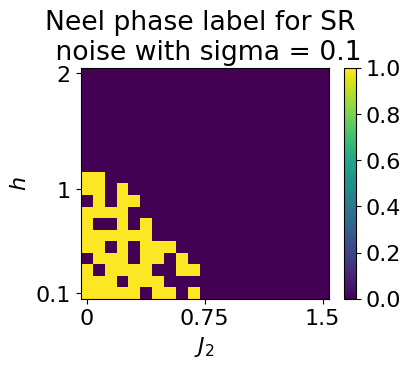

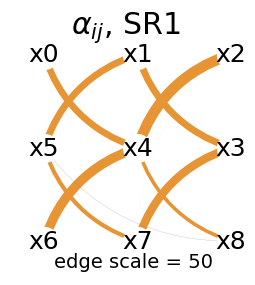

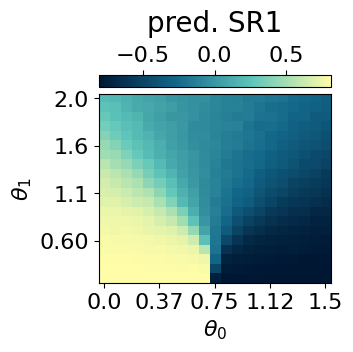

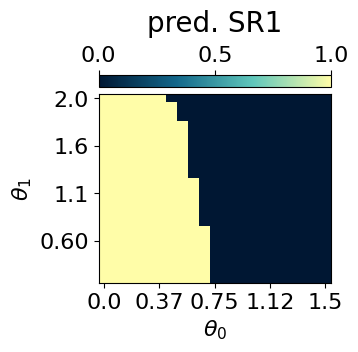

In in in: 100.00%, in in out: 0.00%, out in in: 8.20%, out in out: 91.80%, s=0.9894, auc=0.9995
In in in: 100.00%, in in out: 0.00%, out in in: 7.95%, out in out: 92.05%, s=0.9892, auc=0.9996
In in in: 100.00%, in in out: 0.00%, out in in: 9.92%, out in out: 90.08%, s=0.9896, auc=0.9996
In in in: 100.00%, in in out: 0.00%, out in in: 8.20%, out in out: 91.80%, s=0.9896, auc=0.9997
In in in: 100.00%, in in out: 0.00%, out in in: 8.94%, out in out: 91.06%, s=0.9899, auc=0.9996
In in in: 100.00%, in in out: 0.00%, out in in: 6.67%, out in out: 93.33%, s=0.9892, auc=0.9996
In in in: 100.00%, in in out: 0.00%, out in in: 7.69%, out in out: 92.31%, s=0.9895, auc=0.9996
In in in: 100.00%, in in out: 0.00%, out in in: 7.69%, out in out: 92.31%, s=0.9899, auc=0.9996
In in in: 100.00%, in in out: 0.00%, out in in: 7.44%, out in out: 92.56%, s=0.9896, auc=0.9996
In in in: 100.00%, in in out: 0.00%, out in in: 7.44%, out in out: 92.56%, s=0.9896, auc=0.9995


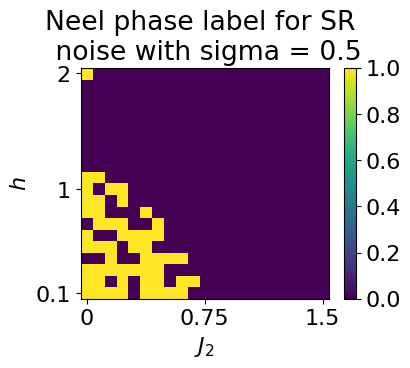

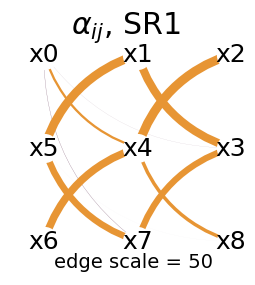

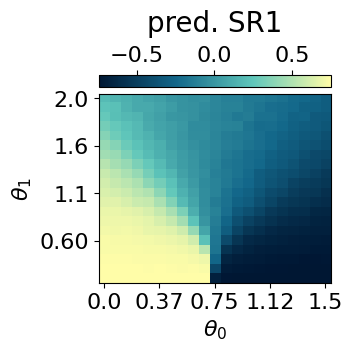

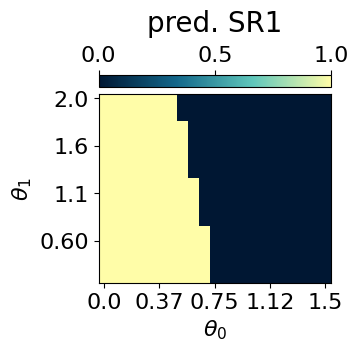

In in in: 98.11%, in in out: 1.89%, out in in: 8.72%, out in out: 91.28%, s=0.9898, auc=0.9996
In in in: 98.18%, in in out: 1.82%, out in in: 8.22%, out in out: 91.78%, s=0.9892, auc=0.9996
In in in: 98.39%, in in out: 1.61%, out in in: 6.42%, out in out: 93.58%, s=0.9896, auc=0.9995
In in in: 98.33%, in in out: 1.67%, out in in: 6.94%, out in out: 93.06%, s=0.9896, auc=0.9996
In in in: 100.00%, in in out: 0.00%, out in in: 8.20%, out in out: 91.80%, s=0.9890, auc=0.9995
In in in: 100.00%, in in out: 0.00%, out in in: 8.45%, out in out: 91.55%, s=0.9895, auc=0.9995
In in in: 100.00%, in in out: 0.00%, out in in: 8.20%, out in out: 91.80%, s=0.9892, auc=0.9998
In in in: 96.00%, in in out: 4.00%, out in in: 9.73%, out in out: 90.27%, s=0.9900, auc=0.9996
In in in: 100.00%, in in out: 0.00%, out in in: 8.45%, out in out: 91.55%, s=0.9895, auc=0.9995
In in in: 96.72%, in in out: 3.28%, out in in: 6.96%, out in out: 93.04%, s=0.9897, auc=0.9996


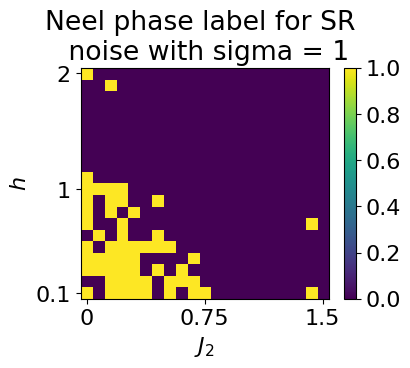

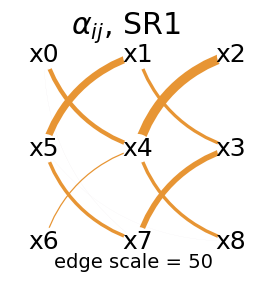

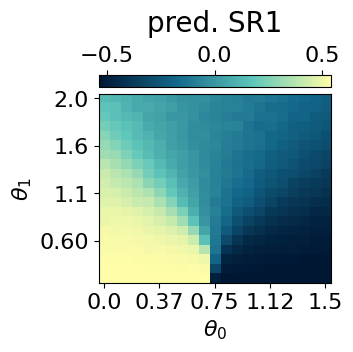

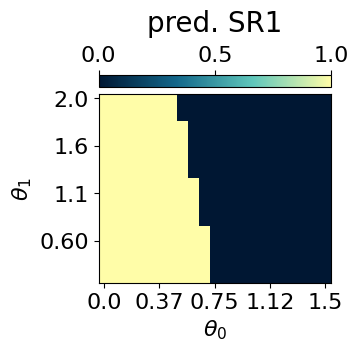

In in in: 89.29%, in in out: 10.71%, out in in: 9.34%, out in out: 90.66%, s=0.9898, auc=0.9995
In in in: 85.96%, in in out: 14.04%, out in in: 9.64%, out in out: 90.36%, s=0.9896, auc=0.9995
In in in: 91.23%, in in out: 8.77%, out in in: 8.82%, out in out: 91.18%, s=0.9890, auc=0.9995
In in in: 80.65%, in in out: 19.35%, out in in: 9.50%, out in out: 90.50%, s=0.9898, auc=0.9997
In in in: 89.29%, in in out: 10.71%, out in in: 9.34%, out in out: 90.66%, s=0.9895, auc=0.9996
In in in: 94.74%, in in out: 5.26%, out in in: 8.26%, out in out: 91.74%, s=0.9895, auc=0.9996
In in in: 91.07%, in in out: 8.93%, out in in: 9.07%, out in out: 90.93%, s=0.9895, auc=0.9996
In in in: 90.20%, in in out: 9.80%, out in in: 10.30%, out in out: 89.70%, s=0.9894, auc=0.9996
In in in: 92.16%, in in out: 7.84%, out in in: 10.03%, out in out: 89.97%, s=0.9894, auc=0.9996
In in in: 87.50%, in in out: 12.50%, out in in: 9.62%, out in out: 90.38%, s=0.9891, auc=0.9995


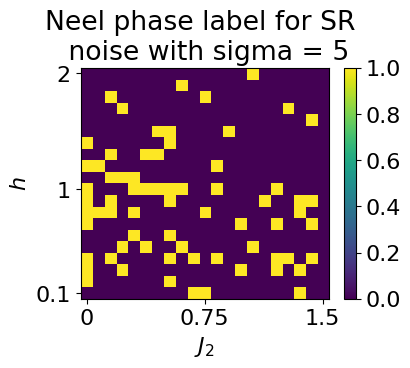

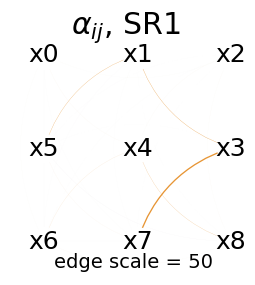

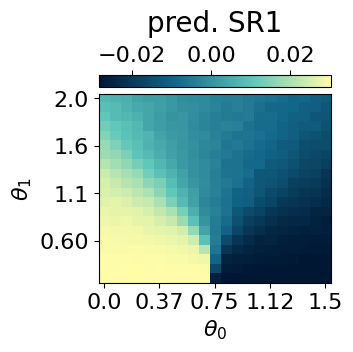

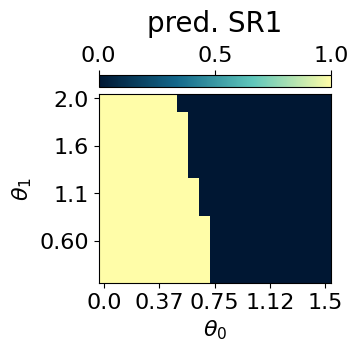

In in in: 34.72%, in in out: 65.28%, out in in: 16.81%, out in out: 83.19%, s=0.9901, auc=0.9996
In in in: 41.67%, in in out: 58.33%, out in in: 15.47%, out in out: 84.53%, s=0.9893, auc=0.9996
In in in: 32.88%, in in out: 67.12%, out in in: 17.24%, out in out: 82.76%, s=0.9894, auc=0.9995
In in in: 39.47%, in in out: 60.53%, out in in: 16.43%, out in out: 83.57%, s=0.9901, auc=0.9998
In in in: 38.75%, in in out: 61.25%, out in in: 15.54%, out in out: 84.46%, s=0.9944, auc=0.9998
In in in: 44.00%, in in out: 56.00%, out in in: 14.78%, out in out: 85.22%, s=0.9901, auc=0.9996
In in in: 41.03%, in in out: 58.97%, out in in: 15.12%, out in out: 84.88%, s=0.9900, auc=0.9995
In in in: 40.85%, in in out: 59.15%, out in in: 15.76%, out in out: 84.24%, s=0.9898, auc=0.9997
In in in: 41.43%, in in out: 58.57%, out in in: 15.62%, out in out: 84.38%, s=0.9896, auc=0.9997
In in in: 41.10%, in in out: 58.90%, out in in: 15.52%, out in out: 84.48%, s=0.9898, auc=0.9996


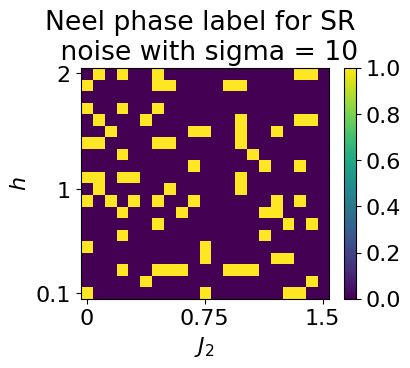

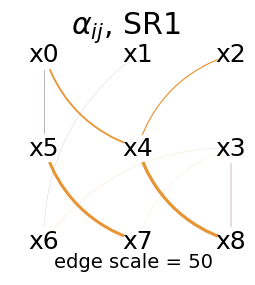

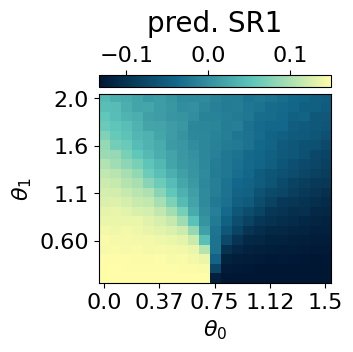

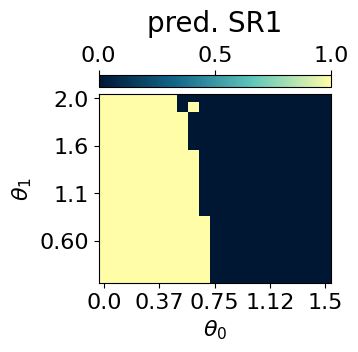

In in in: 23.17%, in in out: 76.83%, out in in: 19.71%, out in out: 80.29%, s=0.9911, auc=0.9996
In in in: 23.75%, in in out: 76.25%, out in in: 19.30%, out in out: 80.70%, s=0.1800, auc=0.7188
In in in: 19.48%, in in out: 80.52%, out in in: 20.06%, out in out: 79.94%, s=0.9566, auc=0.9965
In in in: 27.85%, in in out: 72.15%, out in in: 18.39%, out in out: 81.61%, s=0.9894, auc=0.9998
In in in: 18.07%, in in out: 81.93%, out in in: 19.94%, out in out: 80.06%, s=0.7371, auc=0.9769
In in in: 33.33%, in in out: 66.67%, out in in: 16.95%, out in out: 83.05%, s=0.9906, auc=0.9996
In in in: 24.36%, in in out: 75.64%, out in in: 18.84%, out in out: 81.16%, s=0.9874, auc=0.9996
In in in: 25.93%, in in out: 74.07%, out in in: 19.13%, out in out: 80.87%, s=0.9896, auc=0.9998
In in in: 27.16%, in in out: 72.84%, out in in: 18.55%, out in out: 81.45%, s=0.9963, auc=0.9996
In in in: 27.16%, in in out: 72.84%, out in in: 18.21%, out in out: 81.79%, s=0.9899, auc=0.9997


In [ ]:
cluster_idx_in_neel = jnp.argwhere(mu0abs.transpose()<threshold)
c = all_data['corr_exact'][:10,:].reshape(-1)
labels_neel = jnp.zeros_like(jnp.mean(dataset.data, axis=(-1,-2)))
for id in cluster_idx_in_neel:
  labels_neel = labels_neel.at[id[0],id[1]].set(1)   
labels_neel = labels_neel[:10,:].reshape(-1)

topology = [[0,1,2],[5,4,3],[6,7,8]]

key = jax.random.PRNGKey(534)

all_spearman_SR1 = []
all_auc_SR1 = []
all_alpha_SR1 = []
example_labels = []
all_percentage_in_in_in_label = []
all_percentage_in_in_out_label = []
all_percentage_out_in_in_label = []
all_percentage_out_in_out_label = []
example_pred = []
all_l1 = [5, 5, 5, 2, 0.5]

for j, sigma in enumerate([0.1, 0.5, 1, 5, 10]):
    all_s = []
    all_auc = []
    all_alpha = []
    percentage_in_in_in_label = []
    percentage_in_in_out_label = []
    percentage_out_in_in_label = []
    percentage_out_in_out_label = []
    l1 = all_l1[j]
    for i in range(10):
                  
        key, subkey = jax.random.split(key)
        cluster_idx_in_neel_noisy = cluster_idx_in_neel + sigma*jax.random.normal(subkey, jnp.shape(cluster_idx_in_neel))
        cluster_idx_in_neel_noisy = cluster_idx_in_neel_noisy.astype(jnp.int64)
        #remove duplicate
        cluster_idx_in_neel_noisy = jnp.array(list(set([tuple(idx.tolist()) for idx in cluster_idx_in_neel_noisy])))
        #keep inside
        cluster_idx_in_neel_noisy = cluster_idx_in_neel_noisy%20
        
        if i == 0:
            labels_neel_noisy = jnp.zeros_like(jnp.mean(dataset.data, axis=(-1,-2)))
            for id in cluster_idx_in_neel_noisy:
              labels_neel_noisy = labels_neel_noisy.at[id[0],id[1]].set(1)   
            example_labels.append(labels_neel_noisy)
            
            plt.rcParams['font.size'] = 16
            plt.figure(figsize=(4,3),dpi=100)
            
            plt.imshow(jnp.rot90(labels_neel_noisy), aspect='auto')
            plt.colorbar()
            plt.title('Neel phase label for SR \n noise with sigma = {}'.format(sigma))
            plt.yticks([0,10,19], ['2', '1', '0.1'])
            plt.xticks([0, 10, 20], ['0', '0.75', '1.5'])
            plt.ylabel(r'$h$')
            plt.xlabel(r'$J_2$')
            plt.show()
        
    
        ## perform SR1 on the neel phase ##
    
        mySR = SymbolicRegression(dataset, cluster_idx_in_neel_noisy, objective='SR1', search_space = "2_body_correlator")
        key, subkey = jax.random.split(key)
        res = mySR.train(subkey, dataset_size=2000, print_info = False, L1_reg = l1)
    
        all_alpha.append(mySR.model.alpha)
        if i == 0:
            mySR.plot_alpha(topology=topology, edge_scale=50, name='SR1')
        
        if i == 0:
            p = mySR.compute_and_plot_prediction(name='SR1')
            _ = mySR.compute_and_plot_prediction(name='SR1', class_pred=True)
            example_pred.append(p)
        else:
            p = mySR.compute_prediction()
        a = p[:,:10].transpose().reshape(-1)
        s = jnp.abs(spearman_rho(a, c))
        
        all_s.append(s)
        
        scores = p.transpose()[:10,:].reshape(-1)
        auc = auc_from_scores_labels(scores, labels_neel)

        if auc < 0.5:
            auc = 1 - auc
        
        all_auc.append(auc)
      

        parameter_space_shape = [len(dataset.thetas[i]) for i in range(len(dataset.thetas))]
        grid = jnp.indices(parameter_space_shape)      # (k, ...)
        grid = grid.reshape(len(parameter_space_shape), -1).T  # (N, k)
        equal = jnp.all(grid[:, None, :] == cluster_idx_in_neel[None, :, :], axis=-1)
        in_cluster = jnp.any(equal, axis=1)
        cluster_idx_out_neel = grid[~in_cluster]

        cluster_idx_out_neel_noisy = mySR.cluster_idx_out

        in_in_in_label = sum([(jnp.sum(jnp.array([idx == o for o in cluster_idx_in_neel]), axis=-1) == 2).any() for idx in cluster_idx_in_neel_noisy])/jnp.shape(cluster_idx_in_neel_noisy)[0]
        percentage_in_in_in_label.append(in_in_in_label)

        in_in_out_label = sum([(jnp.sum(jnp.array([idx == o for o in cluster_idx_out_neel]), axis=-1) == 2).any() for idx in cluster_idx_in_neel_noisy])/jnp.shape(cluster_idx_in_neel_noisy)[0]
        percentage_in_in_out_label.append(in_in_out_label)
     
        out_in_in_label = sum([(jnp.sum(jnp.array([idx == o for o in cluster_idx_in_neel]), axis=-1) == 2).any() for idx in cluster_idx_out_neel_noisy])/jnp.shape(cluster_idx_out_neel_noisy)[0]
        percentage_out_in_in_label.append(out_in_in_label)

        out_in_out_label = sum([(jnp.sum(jnp.array([idx == o for o in cluster_idx_out_neel]), axis=-1) == 2).any() for idx in cluster_idx_out_neel_noisy])/jnp.shape(cluster_idx_out_neel_noisy)[0]
        percentage_out_in_out_label.append(out_in_out_label)
        
        print('In in in: {:.2f}%, in in out: {:.2f}%, out in in: {:.2f}%, out in out: {:.2f}%, s={:.4f}, auc={:.4f}'.format(in_in_in_label*100, in_in_out_label*100, out_in_in_label*100, out_in_out_label*100, s,auc))

    all_spearman_SR1.append(all_s)
    all_alpha_SR1.append(all_alpha)
    all_auc_SR1.append(all_auc)
    all_percentage_in_in_in_label.append(percentage_in_in_in_label)
    all_percentage_in_in_out_label.append(percentage_in_in_out_label)
    all_percentage_out_in_in_label.append(percentage_out_in_in_label)
    all_percentage_out_in_out_label.append(percentage_out_in_out_label)


all_data_robustness_SR1_l1 = {}
all_data_robustness_SR1_l1['spearman'] = all_spearman_SR1
all_data_robustness_SR1_l1['alpha'] = all_alpha_SR1
all_data_robustness_SR1_l1['auc'] = all_auc_SR1
all_data_robustness_SR1_l1['in_in_in'] = all_percentage_in_in_in_label
all_data_robustness_SR1_l1['out_in_out'] = all_percentage_out_in_out_label
all_data_robustness_SR1_l1['example_label'] = example_labels
all_data_robustness_SR1_l1['example_pred'] = example_pred

In [ ]:
all_spearman_SR1 = jnp.array(all_data_robustness_SR1_l1['spearman'])
all_auc_SR1 = jnp.array(all_data_robustness_SR1_l1['auc'])
all_percentage_in_in_in_label = jnp.array(all_data_robustness_SR1_l1['in_in_in'])
all_percentage_out_in_out_label = jnp.array(all_data_robustness_SR1_l1['out_in_out'])


print('all percentage noisy in labels:')
for (m,s) in zip(jnp.mean(all_percentage_in_in_in_label, axis=-1), jnp.std(all_percentage_in_in_in_label, axis=-1)):
    print(str(m) + ' +/- ' + str(s))

print('\n')

print('all percentage noisy out labels:')
for (m,s) in zip(jnp.mean(all_percentage_out_in_out_label, axis=-1), jnp.std(all_percentage_out_in_out_label, axis=-1)):
    print(str(m) + ' +/- ' + str(s))

print('\n')

print('all spearman measures:')
for (m,s) in zip(jnp.mean(all_spearman_SR1, axis=-1), jnp.std(all_spearman_SR1, axis=-1)):
    print(str(m) + ' +/- ' + str(s))

print('\n')

print('all auc measures:')
for (m,s) in zip(jnp.mean(all_auc_SR1, axis=-1), jnp.std(all_auc_SR1, axis=-1)):
    print(str(m) + ' +/- ' + str(s))

all percentage noisy in labels:
1.0 +/- 0.0
0.9857367673119248 +/- 0.013656801692738989
0.892070784171054 +/- 0.03668274721250923
0.3958844587158889 +/- 0.03201992493003883
0.25026086288284044 +/- 0.041414925496558286


all percentage noisy out labels:
0.9198713763119933 +/- 0.00851568845740198
0.9197117567951875 +/- 0.009325132372965294
0.90609318959602 +/- 0.005534555650200096
0.8417072480828293 +/- 0.007258098750725972
0.8109166141895623 +/- 0.008913566390989482


all spearman measures:
0.98953915 +/- 0.00022990434
0.98950595 +/- 0.00028956815
0.98945135 +/- 0.00025483983
0.99025697 +/- 0.0014153396
0.8808136 +/- 0.24534683


all auc measures:
0.9995792282430213 +/- 5.5266469695532396e-05
0.9995689655172413 +/- 8.946836912029063e-05
0.9995587027914614 +/- 6.571350818381236e-05
0.999630541871921 +/- 0.00010465967802940789
0.9689860426929393 +/- 0.08366616680821075


We see that incorporating $\text{L1}$ regularization further enhances both performance and stability. The structure of the learned two-body coefficients remains largely intact up to $\sigma^2 \sim 1$ (corresponding to $\mathrm{\sim10\%}$ of false labels). Even with high levels of noise, SR1 with the $\text{L1}$ regularization is able to learn structures close to the NNN correlator. In addition, the predicted function $f(x)$ consistently highlights the Néel phase across all noise levels considered, underscoring the robustness of the SR1 approach.

In [ ]:
## saving the data :) ##

all_data['robustness_SR1'] = all_data_robustness_SR1
all_data['robustness_SR1_l1'] = all_data_robustness_SR1_l1

with open('J1J2_data_cpVAE2_QDisc.pkl', 'wb') as f:
    pickle.dump(all_data, f)

## Genetic search

To benchmark the symbolic regression methods under controlled and comparable conditions, we have restricted the search to the 2-body correlator Ansatz thereby limiting the exploration to a class of functions consistent with prior knowledge. 

However, some prior knowledge may not always be available. In such cases, genetic-algorithm-based approaches enable the exploration of vast spaces of mathematical expressions by combining a defined set of elementary operations (e.g., +, -, *, exp(), sin(), ...) up to a prescribed level of complexity. To do so, `qdisc` call `PySR`. Further details can be found on [GitHub](https://github.com/MilesCranmer/PySR) or
[arXiv](https://arxiv.org/abs/2305.01582).

We will now examine the performance of the genetic search when looking at the symbolic expression that classifies the Néel configurations. 

### search

In [ ]:
## we perform SR1 on the neel phase using the "genetic" search space ##

mySR = SymbolicRegression(dataset, cluster_idx_in_neel, objective='SR1', search_space = "genetic")
key = jax.random.PRNGKey(3246)
res = mySR.train(key, 
                 dataset_size=2000, 
                 random_state = 2575,     # seed for reproductibility
                 niterations = 200,       # Number of iterations to search
                 binary_operators = ["+", "*", "/", "-"], #Allowed binary operations
                 unary_operators = ["exp", "log", "sin", "cos", "tanh"], #Other allowed operations
                 maxsize = 30,            # max complexity of the equations
                 progress = True,         # Show progress during training
                 extra_sympy_mappings = {"C": "C"}, # Allow PySR to use constants
                 batching = True, #batching, usually big dataset
                 batch_size = 500)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
PySRRegressor imported


/home/paulin_ds/qdisc/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
┌ Warning: #= /home/paulin_ds/.julia/packages/DynamicExpressions/cYbpm/ext/DynamicExpressionsLoopVectorizationExt.jl:212 =#:
│ `LoopVectorization.check_args` on your inputs failed; running fallback `@inbounds @fastmath` loop instead.
│ Use `warn_check_args=false`, e.g. `@turbo warn_check_args=false ...`, to disable this warning.
└ @ DynamicExpressionsLoopVectorizationExt ~/.julia/packages/LoopVectorization/GKxH5/src/condense_loopset.jl:1166
┌ Warning: #= /home/paulin_ds/.julia/packages/DynamicExpressions/cYbpm/ext/DynamicExpressionsLoopVectorizationExt.jl:142 =#:
│ `LoopVectorization.check_args` on your inputs failed; running fallback `@inbounds @fastmath` loop instead.
│ Use `warn_check_args=false`, e.g. `@turbo warn_check_args=false ...`, to disable this warning.
└ @ Dyna


Expressions evaluated per second: 3.210e+03
Progress: 105 / 6200 total iterations (1.694%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.931e-01  0.000e+00  y = -0.0067747
3           5.070e-01  1.564e-01  y = x₇ / x₃
5           4.486e-01  6.121e-02  y = x₄ * (x₂ + x₀)
7           4.231e-01  2.930e-02  y = ((x₃ + x₅) * x₇) + -0.35102
9           4.016e-01  2.602e-02  y = ((x₁ * x₅) + -1.0676) + (x₄ / x₂)
11          3.569e-01  5.897e-02  y = (((x₃ * x₇) + (x₅ * x₁)) + -1.001) * 1.6273
13          3.329e-01  3.485e-02  y = ((x₄ * x₆) + ((x₁ * x₅) + -1.0676)) + (x₂ / x₄)
25          3.308e-01  5.257e-04  y = ((((x₇ + -1.4629) - x₇) - (((x₃ * 0.60741) - x₈) * x₄)...
                                      ) + -0.22969) + ((x₃ / x₁) - ((-1.0286 / x₄) * x₀))
27          3.169e-01  2

[ Info: Final population:
[ Info: Results saved to:


  - outputs/20260401_141505_igarmw/hall_of_fame.csv


### results

The results are the final population of symbolic expressions, ordered by complexity. Specifically, `qdisc` returns each expression alongside its prediction accuracy and the terms it is composed of.  

In [ ]:
all_perf, all_eqs, all_terms = res

#look at the expression with the best performance
i = jnp.argmax(jnp.array(all_perf))
print('Expression with the highest accuracy is: Equation {} with accuracy: {}'.format(i,all_perf[i]))
print('It is composed of the following terms: {}'.format(all_terms[i]))
print('The entire expression is:')
print(all_eqs[i])

Expression with the highest accuracy is: Equation 10 with accuracy: 0.906000018119812
It is composed of the following terms: [1, x0*x4, x1*x3, x1*x5, x2*x4, x3*x7, x4*x6, x4*x8, x5*x7]
The entire expression is:
0.633807909681866*x0*x4 + 0.633807909681866*x1*x3 + 0.633807909681866*x1*x5 + 0.633807909681866*x2*x4 + 0.633807909681866*x3*x7 + 0.633807909681866*x4*x6 + 0.633807909681866*x4*x8 + 0.633807909681866*x5*x7 - 2.44719572007265


We observe that the expression achieving the highest prediction accuracy, corresponds exactly to the next-nearest neighbour correlator (up to a constant term). We emphasise that, in this case, the search space contains functions with any order of correlations (up to the predefined maximum complexity).